<a href="https://colab.research.google.com/github/Sahana200301/UNIFIED-MENTOR-DATA-ANALYST-PROJECTS/blob/main/World_Population_Growth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Necessary Libraries

In [7]:
!pip install plotly --quiet

import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('world_population.csv')
print(df.shape)
print(df.columns)
df.head()

(234, 17)
Index(['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent',
       '2022 Population', '2020 Population', '2015 Population',
       '2010 Population', '2000 Population', '1990 Population',
       '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)',
       'Growth Rate', 'World Population Percentage'],
      dtype='object')


,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


# Data Cleaning

In [3]:
# Drop irrelevant columns
df.drop(['CCA3', 'Capital'], axis=1, inplace=True)

print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

Rank                           0
Country/Territory              0
Continent                      0
2022 Population                0
2020 Population                0
2015 Population                0
2010 Population                0
2000 Population                0
1990 Population                0
1980 Population                0
1970 Population                0
Area (km²)                     0
Density (per km²)              0
Growth Rate                    0
World Population Percentage    0
dtype: int64


# Feature Engineering — Population Sustainability Score (PSS)

We'll use this formula:

**PSS = (Growth Rate / Density) × (Area / Population)**

In [4]:
# numerical columns are cleaned and converted
df['2022 Population'] = df['2022 Population'].astype(float)
df['Density (per km²)'] = df['Density (per km²)'].astype(float)
df['Area (km²)'] = df['Area (km²)'].astype(float)
df['Growth Rate'] = df['Growth Rate'].astype(float)

# Calculate PSS
df['PSS'] = (df['Growth Rate'] / df['Density (per km²)']) * (df['Area (km²)'] / df['2022 Population'])
df['PSS'] = df['PSS'].round(6)

df[['Country/Territory', 'PSS']].sort_values(by='PSS', ascending=False).head(10)

,Country/Territory,PSS
78,Greenland,1475.644954
64,Falkland Islands,10.416161
230,Western Sahara,0.217195
135,Mongolia,0.215034
141,Namibia,0.104953
11,Australia,0.087198
69,French Guiana,0.077028
91,Iceland,0.076820
86,Guyana,0.071023
199,Suriname,0.070834


Plot Top 5 Countries by PSS

In [6]:
top_pss = df.sort_values(by='PSS', ascending=False).head(5)

fig = px.bar(top_pss, x='Country/Territory', y='PSS',
             title='Top 10 Countries by Population Sustainability Score',
             color='PSS', color_continuous_scale='Viridis')
fig.show()

# Clustering Countries by Population Growth & Sustainability

In [8]:
cluster_data = df[['Growth Rate', 'PSS']].copy()

# Scale the features (standardization improves clustering performance)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_data)

# Fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

In [10]:
color_map = {0: 'Cluster A', 1: 'Cluster B', 2: 'Cluster C'}
df['Cluster_Label'] = df['Cluster'].map(color_map)

fig = px.scatter(df, x='Growth Rate', y='PSS', color='Cluster_Label',
                 hover_name='Country/Territory',
                 title='Clustering Countries Based on Growth & Sustainability',
                 color_discrete_sequence=px.colors.qualitative.Set1)

fig.update_yaxes(type='log')
fig.show()

In [11]:
# Print number of countries per cluster
print("📦 Cluster distribution:")
print(df['Cluster_Label'].value_counts())

for label in df['Cluster_Label'].unique():
    print(f"\n🌍 Countries in {label}:")
    countries = df[df['Cluster_Label'] == label]['Country/Territory'].tolist()
    print(", ".join(countries))

📦 Cluster distribution:
Cluster_Label
Cluster C    143
Cluster A     90
Cluster B      1
Name: count, dtype: int64

🌍 Countries in Cluster A:
Afghanistan, Algeria, Angola, Belize, Benin, Bolivia, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Djibouti, DR Congo, Egypt, Equatorial Guinea, Eritrea, Ethiopia, French Guiana, Gabon, Gambia, Ghana, Guatemala, Guinea, Guinea-Bissau, Haiti, Honduras, Hungary, Iraq, Israel, Ivory Coast, Jordan, Kenya, Kiribati, Kyrgyzstan, Laos, Liberia, Luxembourg, Macau, Madagascar, Malawi, Mali, Malta, Mauritania, Mayotte, Moldova, Mongolia, Mozambique, Namibia, Nauru, Nepal, Nicaragua, Niger, Nigeria, Oman, Pakistan, Palestine, Panama, Papua New Guinea, Philippines, Poland, Republic of the Congo, Romania, Rwanda, Samoa, Sao Tome and Principe, Saudi Arabia, Senegal, Sierra Leone, Slovakia, Solomon Islands, Somalia, South Sudan, Sudan, Syria, Tajikistan, Tanzania, Timor-Leste, Togo, Tokelau, Turkmenistan, Turks and Caicos 


📊 Population Forecast for India till 2040:
   Year  Predicted Population
0  2025          1.452737e+09
1  2026          1.462752e+09
2  2027          1.472134e+09
3  2028          1.480861e+09
4  2029          1.488911e+09


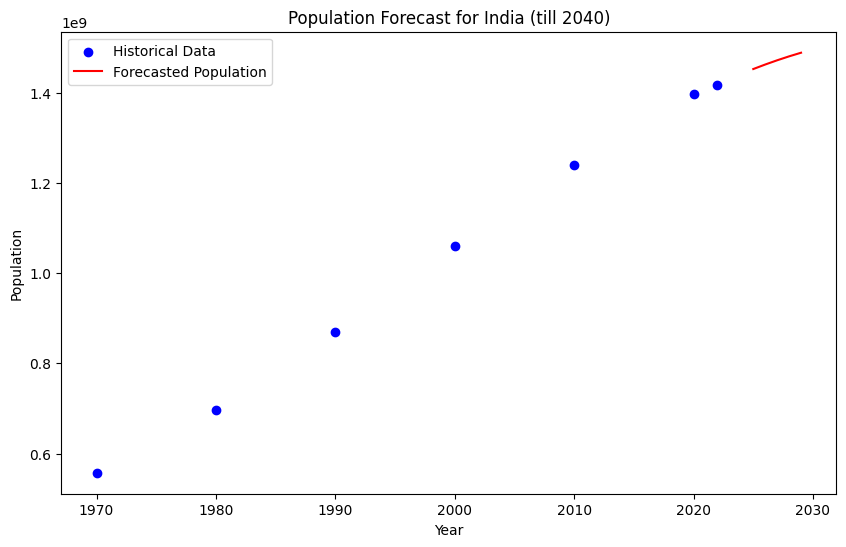

,Year,Predicted Population
0,2025,1.452737e+09
1,2026,1.462752e+09
2,2027,1.472134e+09
3,2028,1.480861e+09
4,2029,1.488911e+09


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def forecast_population(df, country_name, degree=3):
    df_country = df[df['Country/Territory'] == country_name]

    if df_country.empty:
        print(f"Data for {country_name} not found.")
        return

    years = ['1970 Population', '1980 Population', '1990 Population',
             '2000 Population', '2010 Population', '2020 Population', '2022 Population']
    population = df_country[years].values.flatten()
    year_labels = [1970, 1980, 1990, 2000, 2010, 2020, 2022]

    years = np.array(year_labels).reshape(-1, 1)
    population = population.reshape(-1)

    # Apply polynomial feature transformation
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(years)

    # Train a polynomial regression model
    model = LinearRegression()
    model.fit(X_poly, population)

    # Create years for the future (up to 2040)
    future_years = np.arange(2025, 2030).reshape(-1, 1)

    future_years_poly = poly.transform(future_years)

    # Predict the population for future years
    forecasted_population = model.predict(future_years_poly)

    # Combine the years and forecasted population into a DataFrame
    forecast_df = pd.DataFrame({
        'Year': future_years.flatten(),
        'Predicted Population': forecasted_population
    })

    print(f"\n📊 Population Forecast for {country_name} till 2040:")
    print(forecast_df)

    plt.figure(figsize=(10, 6))
    plt.scatter(years, population, color='blue', label='Historical Data')
    plt.plot(future_years, forecasted_population, color='red', label='Forecasted Population')

    plt.title(f'Population Forecast for {country_name} (till 2040)')
    plt.xlabel('Year')
    plt.ylabel('Population')
    plt.legend()
    plt.show()

    return forecast_df

forecast_population(df, 'India')